# Preparing the environment and data

**Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

Load Data

In [2]:
df=pd.read_csv('Superstore.csv', encoding='latin-1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
print(df.columns)
print(df.info())
print(df.describe().T)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal

In [4]:
df['Order Date']=pd.to_datetime(df['Order Date'])
df['Ship Date']=pd.to_datetime(df['Ship Date'])
df.dtypes[['Order Date', 'Ship Date']]

,0
Order Date,datetime64[ns]
Ship Date,datetime64[ns]


In [5]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
df.isna().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [7]:
df.duplicated().sum()

np.int64(0)

# Monthly and annual sales analysis

In [8]:
df['YearMonth']=df['Order Date'].dt.to_period('M')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,YearMonth
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016-11
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016-11
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016-06
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015-10
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015-10


In [9]:
Monthly_Sales=df.groupby('YearMonth')[['Sales','Profit']].sum()
print(Monthly_Sales.head())

               Sales     Profit
YearMonth                      
2014-01    14236.895  2450.1907
2014-02     4519.892   862.3084
2014-03    55691.009   498.7299
2014-04    28295.345  3488.8352
2014-05    23648.287  2738.7096


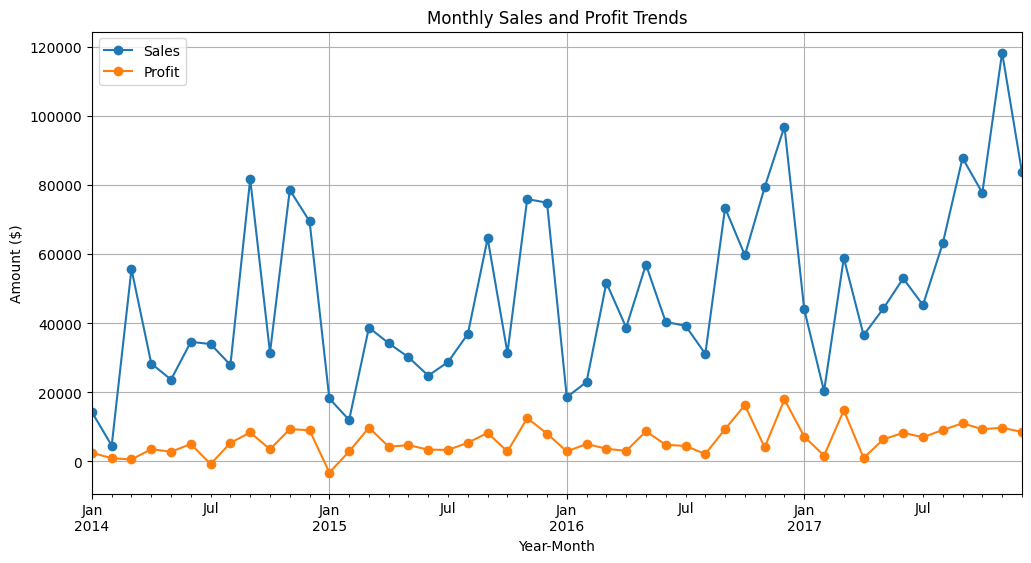

In [10]:
Monthly_Sales.plot(kind='line', figsize=(12,6), marker='o')
plt.title("Monthly Sales and Profit Trends")
plt.xlabel("Year-Month")
plt.ylabel("Amount ($)")
plt.grid(True)
plt.savefig("Monthly Sales and Profit Trends.png")
plt.show()

# Product analysis

In [11]:
Product_Sales = df.groupby('Product Name')[['Sales','Profit']].sum()
print(Product_Sales.head())

                                                      Sales    Profit
Product Name                                                         
"While you Were Out" Message Book, One Form per...   25.228   10.3880
#10 Gummed Flap White Envelopes, 100/Box             41.300   16.7678
#10 Self-Seal White Envelopes                       108.682   52.1230
#10 White Business Envelopes,4 1/8 x 9 1/2          488.904  223.1408
#10- 4 1/8" x 9 1/2" Recycled Envelopes             286.672  115.2806


In [12]:
top_products = Product_Sales.sort_values('Sales', ascending=False).head(10)

print(top_products)

                                                        Sales        Profit
Product Name                                                               
Canon imageCLASS 2200 Advanced Copier               61599.824  2.519993e+04
Fellowes PB500 Electric Punch Plastic Comb Bind...  27453.384  7.753039e+03
Cisco TelePresence System EX90 Videoconferencin...  22638.480 -1.811078e+03
HON 5400 Series Task Chairs for Big and Tall        21870.576  5.684342e-14
GBC DocuBind TL300 Electric Binding System          19823.479  2.233505e+03
GBC Ibimaster 500 Manual ProClick Binding System    19024.500  7.609800e+02
Hewlett Packard LaserJet 3310 Copier                18839.686  6.983884e+03
HP Designjet T520 Inkjet Large Format Printer -...  18374.895  4.094977e+03
GBC DocuBind P400 Electric Binding System           17965.068 -1.878166e+03
High Speed Automatic Electric Letter Opener         17030.312 -2.620048e+02


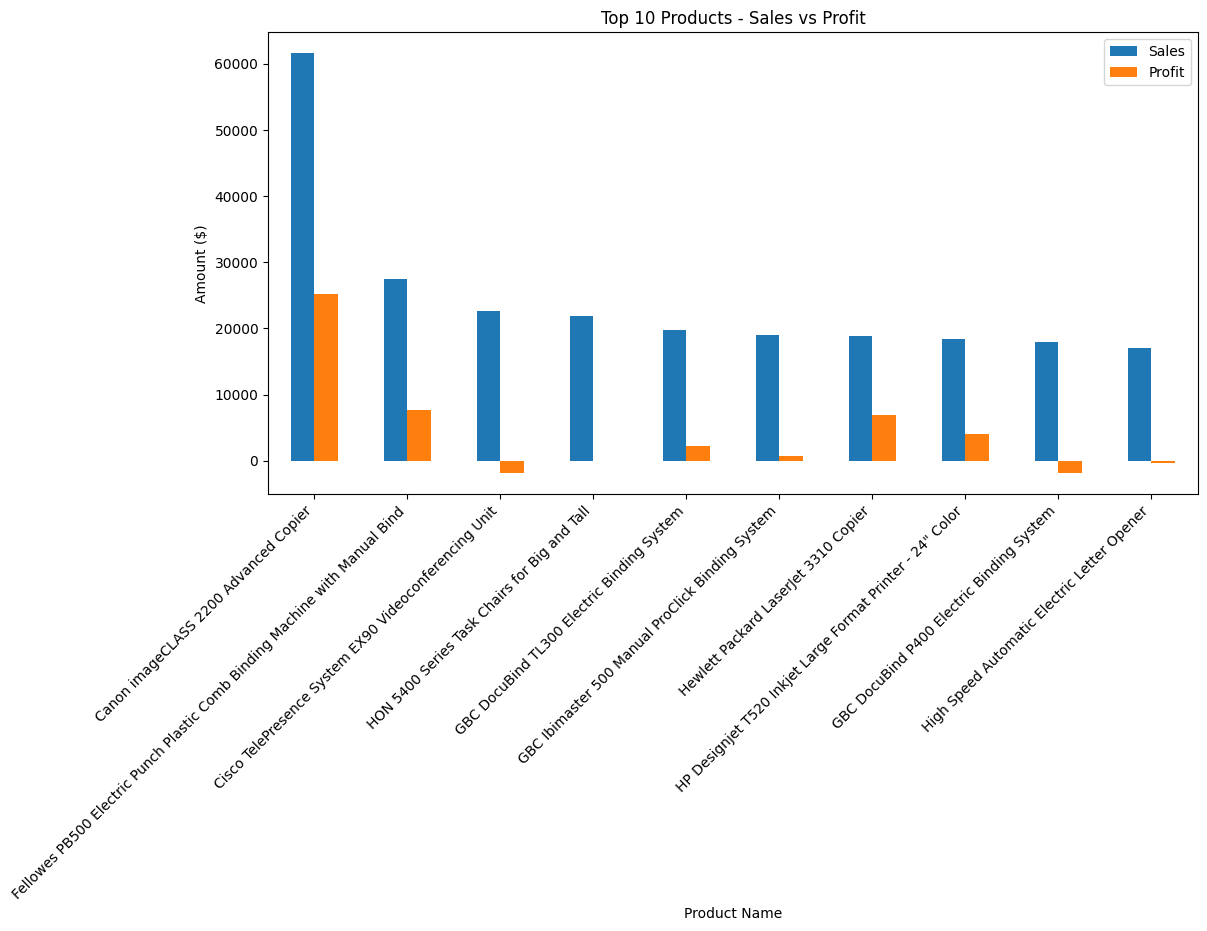

In [13]:
top_products[['Sales','Profit']].plot(kind='bar', figsize=(12,6))
plt.title("Top 10 Products - Sales vs Profit")
plt.xlabel("Product Name")
plt.ylabel("Amount ($)")
plt.xticks(rotation=45, ha='right')
plt.savefig("Top 10 products_Sales vs profit.png")
plt.show()

# Customer analysis

In [14]:
df.Segment.value_counts()

,count
Segment,
Consumer,5191
Corporate,3020
Home Office,1783


In [15]:
segment_sales = df.groupby('Segment')[['Sales','Profit']].sum()

print(segment_sales)

                    Sales       Profit
Segment                               
Consumer     1.161401e+06  134119.2092
Corporate    7.061464e+05   91979.1340
Home Office  4.296531e+05   60298.6785


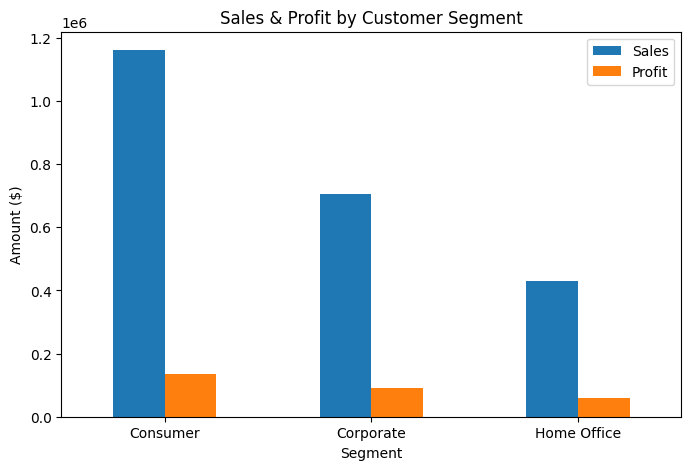

In [16]:
segment_sales[['Sales','Profit']].plot(kind='bar', figsize=(8,5))
plt.title("Sales & Profit by Customer Segment")
plt.ylabel("Amount ($)")
plt.xticks(rotation=0)
plt.savefig("sales_profit_chaet.png")
plt.show()

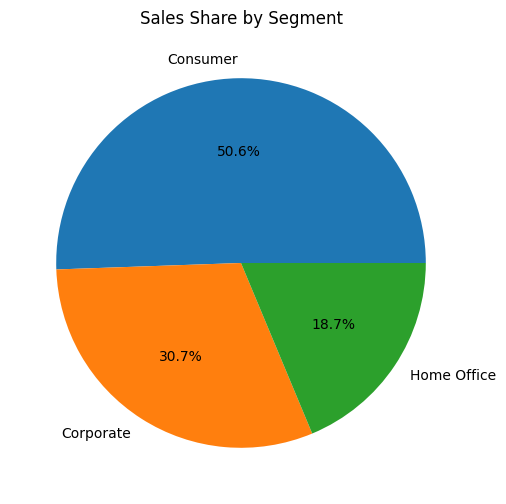

In [17]:
segment_sales['Sales'].plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title("Sales Share by Segment")
plt.ylabel("")  # عشان ما يظهرش النص الجانبي
plt.savefig("Sales Share by Segment.png")
plt.show()

# Region & Category Analysis

In [18]:
print(df.Category.value_counts())
print(df.Region.value_counts())

Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64
Region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64


In [19]:
region_sales = df.groupby('Region')[['Sales','Profit']].sum()
print(region_sales)

               Sales       Profit
Region                           
Central  501239.8908   39706.3625
East     678781.2400   91522.7800
South    391721.9050   46749.4303
West     725457.8245  108418.4489


In [20]:
category_sales = df.groupby('Category')[['Sales','Profit']].sum()
print(category_sales)

                       Sales       Profit
Category                                 
Furniture        741999.7953   18451.2728
Office Supplies  719047.0320  122490.8008
Technology       836154.0330  145454.9481


In [21]:
region_category = df.pivot_table(values=['Sales','Profit'],
                                 index='Region',
                                 columns='Category',
                                 aggfunc='sum')
print(region_category)

              Profit                                    Sales                  \
Category   Furniture Office Supplies  Technology    Furniture Office Supplies   
Region                                                                          
Central   -2871.0494       8879.9799  33697.4320  163797.1638      167026.415   
East       3046.1658      41014.5791  47462.0351  208291.2040      205516.055   
South      6771.2061      19986.3928  19991.8314  117298.6840      125651.313   
West      11504.9503      52609.8490  44303.6496  252612.7435      220853.249   

                      
Category  Technology  
Region                
Central   170416.312  
East      264973.981  
South     148771.908  
West      251991.832  


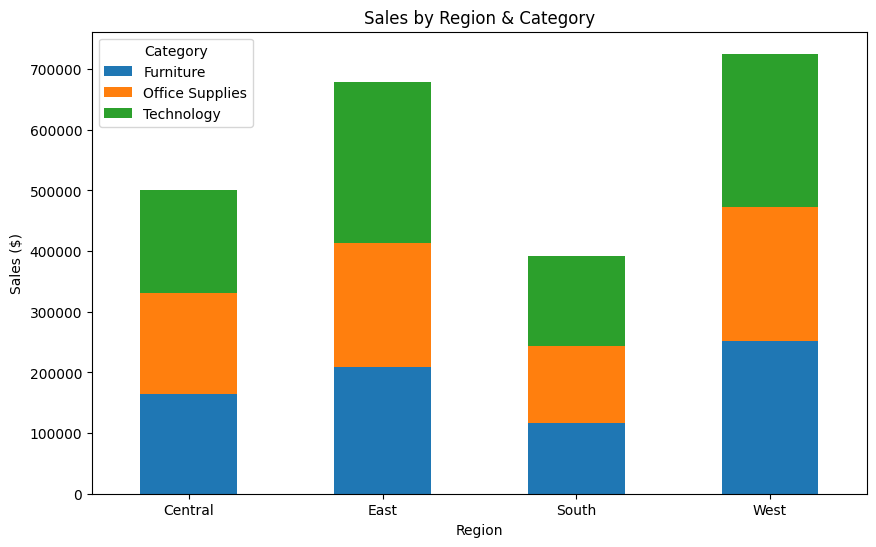

In [22]:
region_category['Sales'].plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Sales by Region & Category")
plt.ylabel("Sales ($)")
plt.xticks(rotation=0)
plt.savefig("Sales by Region & Category.png")
plt.show()

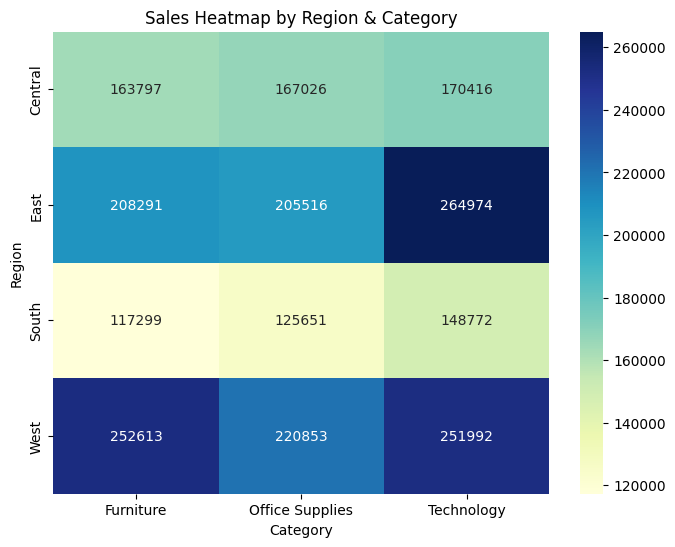

In [23]:
plt.figure(figsize=(8,6))
sns.heatmap(region_category['Sales'], annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Sales Heatmap by Region & Category")
plt.savefig("Sales Heatmap by Region & Category.png")
plt.show()

# Insights

**(1) Sales Share by Segment (Pie Chart)**

Consumer Segment contributes 50.6% of total sales.

Corporate Segment contributes 30.7%.

Home Office Segment contributes 18.7%.


**Insight:**
The Consumer Segment is the most dominant, accounting for half of the total sales.
Marketing campaigns and promotional offers targeting this segment are likely to yield the highest return.
However, the Corporate Segment is also significant and should not be neglected, especially for B2B opportunities.


---

**(2) Monthly Sales & Profit Trends (Line Chart)**

Sales show a steady upward trend over the years, especially from mid-2016 to the end of 2017.

Profits remain relatively low and unstable compared to sales, with some months showing negative profits (losses).

Sales peaks often occur towards the end of the year, likely due to seasonal events or holiday promotions.


**Insight:**
While the company is achieving strong sales growth, profitability is not keeping up, which could indicate high operational costs or aggressive discounting.
A cost and pricing strategy review is needed to improve the profit margin.


---

**(3) Sales & Profit by Customer Segment (Bar Chart)**

Consumer Segment generates the highest sales and profits, but the profit margin is relatively low.

Corporate Segment has good sales but much lower profits, showing potential inefficiencies or pricing issues.

Home Office Segment has the lowest sales and profits.


**Insight:**

Focus on the Consumer Segment to optimize profitability by revising discounts or increasing prices slightly.

The Corporate Segment needs a targeted strategy to increase profitability, possibly through cost reduction or adjusted pricing models.



---

**Executive Summary:**

The Consumer Segment is the main driver of sales but suffers from low profit margins.

Strong sales growth over time is not being matched by profit growth, signaling cost management or pricing issues.

Future strategy should focus on:

1. Improving profit margins through cost optimization and smarter pricing.


2. Leveraging seasonal peaks with strategic marketing campaigns.


3. Developing customized strategies for Corporate and Home Office segments to maximize potential.